# Phase 4: Baseline Benchmarking & Architecture Justification

## Objective
To scientifically validate the complexity of the Deep Factorization Machine (DeepFM), we must compare its predictive performance against standard machine learning baselines.

## Methodology
Using a deterministic seed (`random_state=42`), we recreate the exact 80/20 data split used during the DeepFM training phase. We will train standard algorithmic models (Simple Linear Regression and Decision Trees) on this data. We will then load our pre-trained, frozen DeepFM architecture. Finally, we will evaluate all models on the identical, unseen testing set to observe how predictive power (specifically $R^2$) scales with architectural complexity.

In [1]:
# ==========================================
# 1. ENVIRONMENT SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import joblib
import warnings

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')

# Upgrade device check for MacBook Apple Silicon (MPS)
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print(f"✅ Environment Ready. Compute Device: {device}")

✅ Environment Ready. Compute Device: mps


## Common Data Pipeline & Deterministic Split

To scientifically validate the DeepFM architecture, we must ensure an apples-to-apples comparison. In this phase, we load the `gold_historical_deliveries.csv` and apply the exact same 80/20 deterministic split (`random_state=42`) used previously.

**Data Formatting for Scikit-Learn:**
Unlike PyTorch, which requires data to be converted into Tensors and separated into distinct sparse and dense pipelines, standard Scikit-Learn algorithms expect a single, flat 2D matrix. We will concatenate all features into a unified `X_train` and `X_test` matrix.

In [2]:
# ==========================================
# 2. LOAD DATA & PREPARE FOR SCIKIT-LEARN
# ==========================================
print("📂 Loading Gold Dataset...")
# Use relative path to point to your data folder
df = pd.read_csv('../data/processed/gold_historical_deliveries.csv')

sparse_features = [
    'driver_id', 'prev_customer_id', 'customer_id', 'destination_grid_id',
    'origin_grid_id', 'vehicle_type_id', 'location_type', 'prev_location_type',
    'is_pin_verified', 'weather_code', 'month_of_year', 'day_of_week',
    'hour_of_day', 'prev_cod_friction_code', 'trip_sequence_id', 'trip_progress_id'
]

dense_features = [
    'google_eta_seconds', 'google_distance_meters', 'prev_cod_amount',
    'rain_volume_1h', 'trip_sequence_num', 'trip_progress_ratio'
]

target = 'actual_time_diff_seconds'

# Combine all features for standard ML models
all_features = sparse_features + dense_features

# Deterministic 80/20 Split
X = df[all_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

print(f"✅ Data Split Complete.")
print(f"📦 Training Set: {X_train.shape[0]:,} rows")
print(f"📦 Testing Set:  {X_test.shape[0]:,} rows")

# Global Evaluation Dictionary
model_results = {
    'Model': [],
    'Test_MAE': [],
    'Test_RMSE': [],
    'Test_R2': []
}

def log_results(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    model_results['Model'].append(model_name)
    model_results['Test_MAE'].append(mae)
    model_results['Test_RMSE'].append(rmse)
    model_results['Test_R2'].append(r2)

    print(f"🏆 {model_name} Results:")
    print(f"   - MAE:  {mae:.2f} seconds")
    print(f"   - RMSE: {rmse:.2f} seconds")
    print(f"   - R²:   {r2:.4f}")
    print("-" * 40)

📂 Loading Gold Dataset...
✅ Data Split Complete.
📦 Training Set: 456,352 rows
📦 Testing Set:  114,088 rows


## Baseline 1: Simple Linear Regression

**The Hypothesis:** Linear Regression is the simplest machine learning baseline. It assumes every feature has an independent, constant, and linear relationship with delivery time. It cannot calculate interactions between features. If this model scores poorly, it mathematically proves that Sri Lankan logistics is a highly non-linear problem.

In [3]:
# ==========================================
# 3. TRAIN SIMPLE LINEAR REGRESSION
# ==========================================
print("🚂 Training Baseline 1: Simple Linear Regression...")

slr_model = LinearRegression()
slr_model.fit(X_train, y_train)
slr_preds = slr_model.predict(X_test)

log_results("Linear Regression", y_test, slr_preds)

🚂 Training Baseline 1: Simple Linear Regression...
🏆 Linear Regression Results:
   - MAE:  135.92 seconds
   - RMSE: 219.93 seconds
   - R²:   0.4221
----------------------------------------


## Baseline 2: Decision Tree Regressor

**The Hypothesis:** Unlike Linear Regression, a Decision Tree can map non-linear relationships by splitting the data into a flowchart of "If-Then" rules. However, traditional trees struggle to generalize high-cardinality categorical data (like thousands of unique driver IDs) without severely overfitting the training set.

In [4]:
# ==========================================
# 4. TRAIN DECISION TREE REGRESSOR
# ==========================================
print("🌲 Training Baseline 2: Decision Tree Regressor...")

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

log_results("Decision Tree", y_test, dt_preds)

🌲 Training Baseline 2: Decision Tree Regressor...
🏆 Decision Tree Results:
   - MAE:  44.92 seconds
   - RMSE: 125.05 seconds
   - R²:   0.8132
----------------------------------------


## The Champion Model: DeepFM (Frozen Evaluation)

**The Hypothesis:**
DeepFM solves the scalability and non-linearity limits of traditional models by replacing flat integers with dynamic Embedding Vectors. This allows the model to learn complex relationships (like mapping the friction of specific location grids) in $O(1)$ lookup time, making it infinitely more scalable for enterprise logistics than traditional tree-based ensembles.

In this block, we rebuild the PyTorch blueprint. We will **not** train it. We initialize the empty shell and inject the `lamigo_deepfm_weights.pth` file to test it strictly on the unseen testing set.

In [5]:
# ==========================================
# 5. CUSTOM DEEPFM ARCHITECTURE
# ==========================================
sparse_feature_dims = {feat: df[feat].nunique() for feat in sparse_features}
num_dense = len(dense_features)

class LamiGoDeepFM(nn.Module):
    def __init__(self, sparse_feature_dims, num_dense_features, embed_dim=8, dropout_rate=0.1):
        super(LamiGoDeepFM, self).__init__()

        self.sparse_features = list(sparse_feature_dims.keys())
        self.embed_dim = embed_dim
        self.dropout_rate = dropout_rate

        self.embeddings = nn.ModuleDict({
            feat: nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
            for feat, vocab_size in sparse_feature_dims.items()
        })

        self.fm_1st_order_embeddings = nn.ModuleDict({
            feat: nn.Embedding(num_embeddings=vocab_size, embedding_dim=1)
            for feat, vocab_size in sparse_feature_dims.items()
        })

        self.fm_1st_order_dense = nn.Linear(num_dense_features, 1)

        dnn_input_dim = (len(sparse_feature_dims) * embed_dim) + num_dense_features

        self.dnn = nn.Sequential(
            nn.Linear(dnn_input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)
        )

    def forward(self, x_sparse, x_dense):
        sparse_embeds = [
            self.embeddings[feat](x_sparse[:, i])
            for i, feat in enumerate(self.sparse_features)
        ]
        embed_tensor = torch.stack(sparse_embeds, dim=1)

        if self.training:
            mask = torch.empty(embed_tensor.shape[:2], device=embed_tensor.device).bernoulli_(1 - self.dropout_rate)
            mask = mask.unsqueeze(-1)
            embed_tensor = embed_tensor * mask

        fm_1st_sparse = torch.stack([
            self.fm_1st_order_embeddings[feat](x_sparse[:, i])
            for i, feat in enumerate(self.sparse_features)
        ], dim=1).sum(dim=1)

        fm_1st_dense = self.fm_1st_order_dense(x_dense)
        y_fm_1st = fm_1st_sparse + fm_1st_dense

        sum_of_square = torch.sum(embed_tensor, dim=1) ** 2
        square_of_sum = torch.sum(embed_tensor ** 2, dim=1)
        y_fm_2nd = 0.5 * torch.sum(sum_of_square - square_of_sum, dim=1, keepdim=True)

        embed_flat = embed_tensor.view(embed_tensor.size(0), -1)
        dnn_input = torch.cat([embed_flat, x_dense], dim=1)
        y_dnn = self.dnn(dnn_input)

        final_output = y_fm_1st + y_fm_2nd + y_dnn
        return final_output.squeeze()

print("✅ Custom PyTorch DeepFM Architecture compiled successfully!")

✅ Custom PyTorch DeepFM Architecture compiled successfully!


## Evaluating the Frozen DeepFM Brain

Because PyTorch requires Tensors rather than Pandas DataFrames, we rebuild our Dataset translator to pass the exact same `X_test` data into the neural network, evaluating it with gradients disabled.

In [6]:
# ==========================================
# 6. EVALUATE FROZEN DEEPFM
# ==========================================
print("🧠 Awakening the Frozen DeepFM Brain...")

class LamiGoDeliveryDataset(Dataset):
    def __init__(self, X_df, y_series, sparse_cols, dense_cols):
        self.X_sparse = torch.tensor(X_df[sparse_cols].values, dtype=torch.long)
        self.X_dense = torch.tensor(X_df[dense_cols].values, dtype=torch.float32)
        self.y = torch.tensor(y_series.values, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_sparse[idx], self.X_dense[idx], self.y[idx]

test_dataset = LamiGoDeliveryDataset(X_test, y_test, sparse_features, dense_features)
test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

deepfm_model = LamiGoDeepFM(sparse_feature_dims, num_dense, embed_dim=8, dropout_rate=0.0)
deepfm_model.load_state_dict(torch.load('../models/lamigo_deepfm_weights_Local.pth', map_location=device, weights_only=True))
deepfm_model = deepfm_model.to(device)

deepfm_model.eval()
deepfm_preds = []

with torch.no_grad():
    for x_sparse, x_dense, _ in test_loader:
        x_sparse, x_dense = x_sparse.to(device), x_dense.to(device)
        preds = deepfm_model(x_sparse, x_dense)
        deepfm_preds.extend(preds.cpu().numpy())

log_results("DeepFM (PyTorch)", y_test, deepfm_preds)

🧠 Awakening the Frozen DeepFM Brain...
🏆 DeepFM (PyTorch) Results:
   - MAE:  43.06 seconds
   - RMSE: 92.21 seconds
   - R²:   0.8984
----------------------------------------


## Benchmark Conclusion: The $R^2$ Progression

To visualize the justification for DeepFM, we plot the progression of $R^2$ (Variance Explained). As we move from basic linear logic to simple tree logic, and finally to Deep Learning embeddings, we can physically see the model's ability to capture the chaotic friction of real-world logistics increase.


🏆 FINAL MODEL BENCHMARK RESULTS
            Model   Test_MAE  Test_RMSE  Test_R2
Linear Regression 135.919477 219.929735 0.422056
    Decision Tree  44.915337 125.045360 0.813167
 DeepFM (PyTorch)  43.063002  92.211406 0.898402



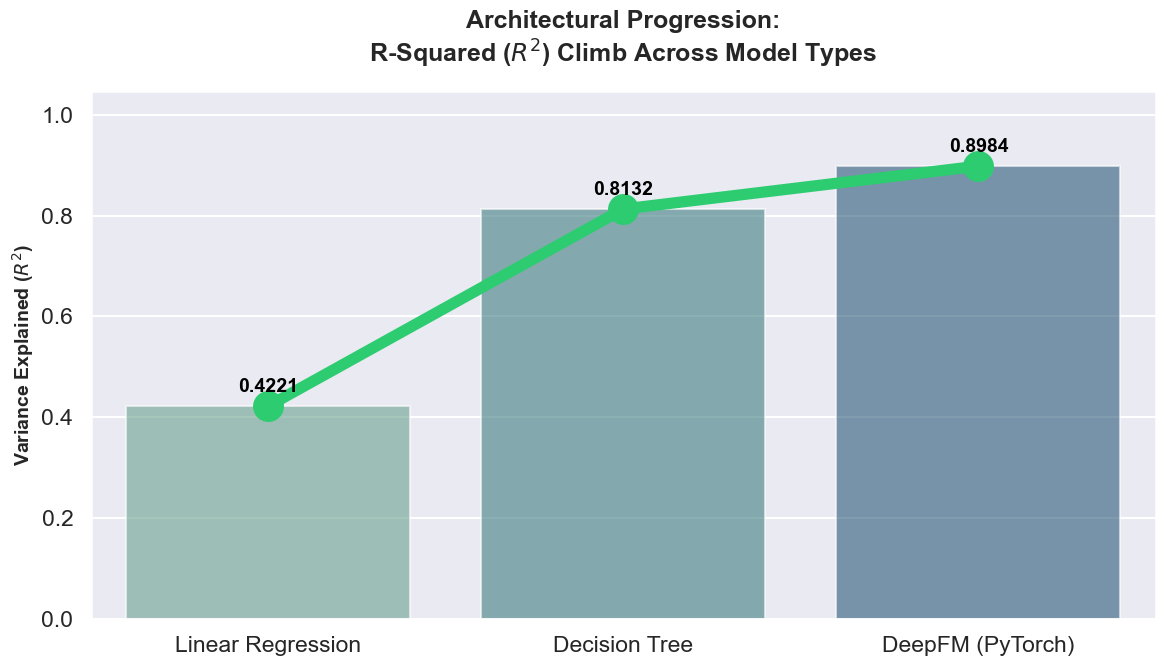

In [7]:
# ==========================================
# 7. VISUALIZE MODEL PROGRESSION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(model_results)

print("\n" + "="*60)
print("🏆 FINAL MODEL BENCHMARK RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60 + "\n")

# Set up the visual canvas
sns.set_theme(style="darkgrid", context="talk")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Create a beautiful line plot connecting the models to show the climb
sns.pointplot(
    data=results_df,
    x='Model',
    y='Test_R2',
    color='#2ecc71',
    markers='o',
    scale=2.0,
    ax=ax1
)

# Overlay bars for aesthetic depth
sns.barplot(
    data=results_df,
    x='Model',
    y='Test_R2',
    palette='crest',
    alpha=0.6,
    ax=ax1
)

# Formatting
ax1.set_title("Architectural Progression:\nR-Squared ($R^2$) Climb Across Model Types", fontsize=18, fontweight='bold', pad=20)
ax1.set_ylabel("Variance Explained ($R^2$)", fontsize=14, fontweight='bold')
ax1.set_xlabel("")
ax1.set_ylim(0, max(results_df['Test_R2']) + 0.15)

# Annotate the exact scores on the graph
for i, val in enumerate(results_df['Test_R2']):
    ax1.text(i, val + 0.02, f"{val:.4f}", ha='center', va='bottom', fontsize=14, fontweight='bold', color='black')

plt.tight_layout()
plt.show()